In [1]:
# Tensorflow / Keras
from tensorflow import keras # for building Neural Networks
print('Tensorflow/Keras: %s' % keras.__version__) # print version
from keras.models import Model, load_model # for assembling a Neural Network model
from keras.layers import Input, Dense, Embedding, Reshape, Concatenate, Flatten, Dropout # for adding layers
from keras.layers import Conv2D, Conv2DTranspose, MaxPool2D, ReLU, LeakyReLU # for adding layers
from tensorflow.keras.utils import plot_model # for plotting model diagram
from tensorflow.keras.optimizers import Adam # for model optimization 

# Data manipulation
import numpy as np # for data manipulation
print('numpy: %s' % np.__version__) # print version

# Visualization
import matplotlib 
import matplotlib.pyplot as plt # for data visualizationa
print('matplotlib: %s' % matplotlib.__version__) # print version
import graphviz # for showing model diagram
print('graphviz: %s' % graphviz.__version__) # print version

# Other utilities
import sys
import os

# Assign main directory to a variable
main_dir="/Users/wangtiles/DSCI601/DSCI601-generative-ai-for-sustainability/Implementation_trial/cDCGAN_MNIST"
print(main_dir)

Tensorflow/Keras: 2.12.0
numpy: 1.23.5
matplotlib: 3.9.2
graphviz: 0.21
/Users/wangtiles/DSCI601/DSCI601-generative-ai-for-sustainability/Implementation_trial/cDCGAN_MNIST


Shape of X_train:  (60000, 28, 28)
Shape of y_train:  (60000,)


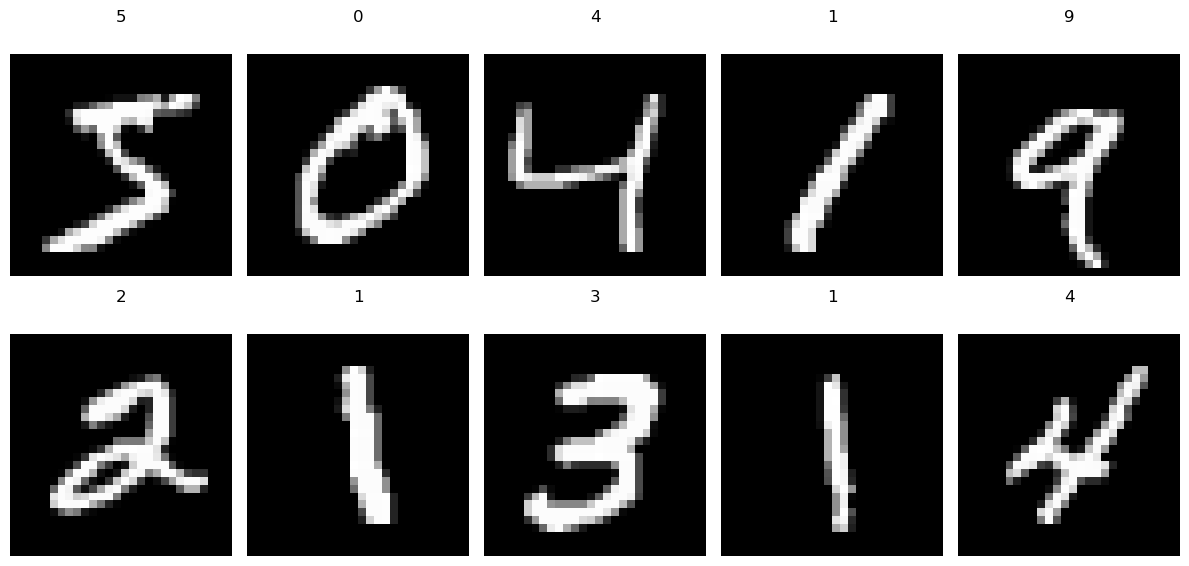

Shape of the scaled array:  (60000, 28, 28, 1)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))
60000


In [14]:
# Load digits data 
(X_train, y_train), (_, _) = keras.datasets.mnist.load_data()

# Print shapes
print("Shape of X_train: ", X_train.shape)
print("Shape of y_train: ", y_train.shape)

# Display images of the first 10 digits in the training set and their true lables
fig, axs = plt.subplots(2, 5, sharey=False, tight_layout=True, figsize=(12,6), facecolor='white')
n=0
for i in range(0,2):
    for j in range(0,5):
        axs[i,j].matshow(X_train[n], cmap='gray')
        axs[i,j].set(title=y_train[n])
        axs[i,j].axis('off')
        n=n+1
plt.show() 

# Scale and reshape as required by the model
data=X_train.copy()
data=data.reshape(X_train.shape[0], 28, 28, 1)
data = (data - 127.5) / 127.5  # Normalize the images to [-1, 1]
print("Shape of the scaled array: ", data.shape)
print(np.unique(y_train, return_counts=True))
print(len(y_train))

Step 3 - Setup GAN

Step 3.1 - Generator model

Model: "Generator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Generator-Latent-Input-Layer (  [(None, 100)]       0           []                               
 InputLayer)                                                                                      
                                                                                                  
 Generator-Label-Input-Layer (I  [(None, 1)]         0           []                               
 nputLayer)                                                                                       
                                                                                                  
 Generator-Foundation-Layer (De  (None, 6272)        633472      ['Generator-Latent-Input-Layer[0]
 nse)                                                            [0]']                    

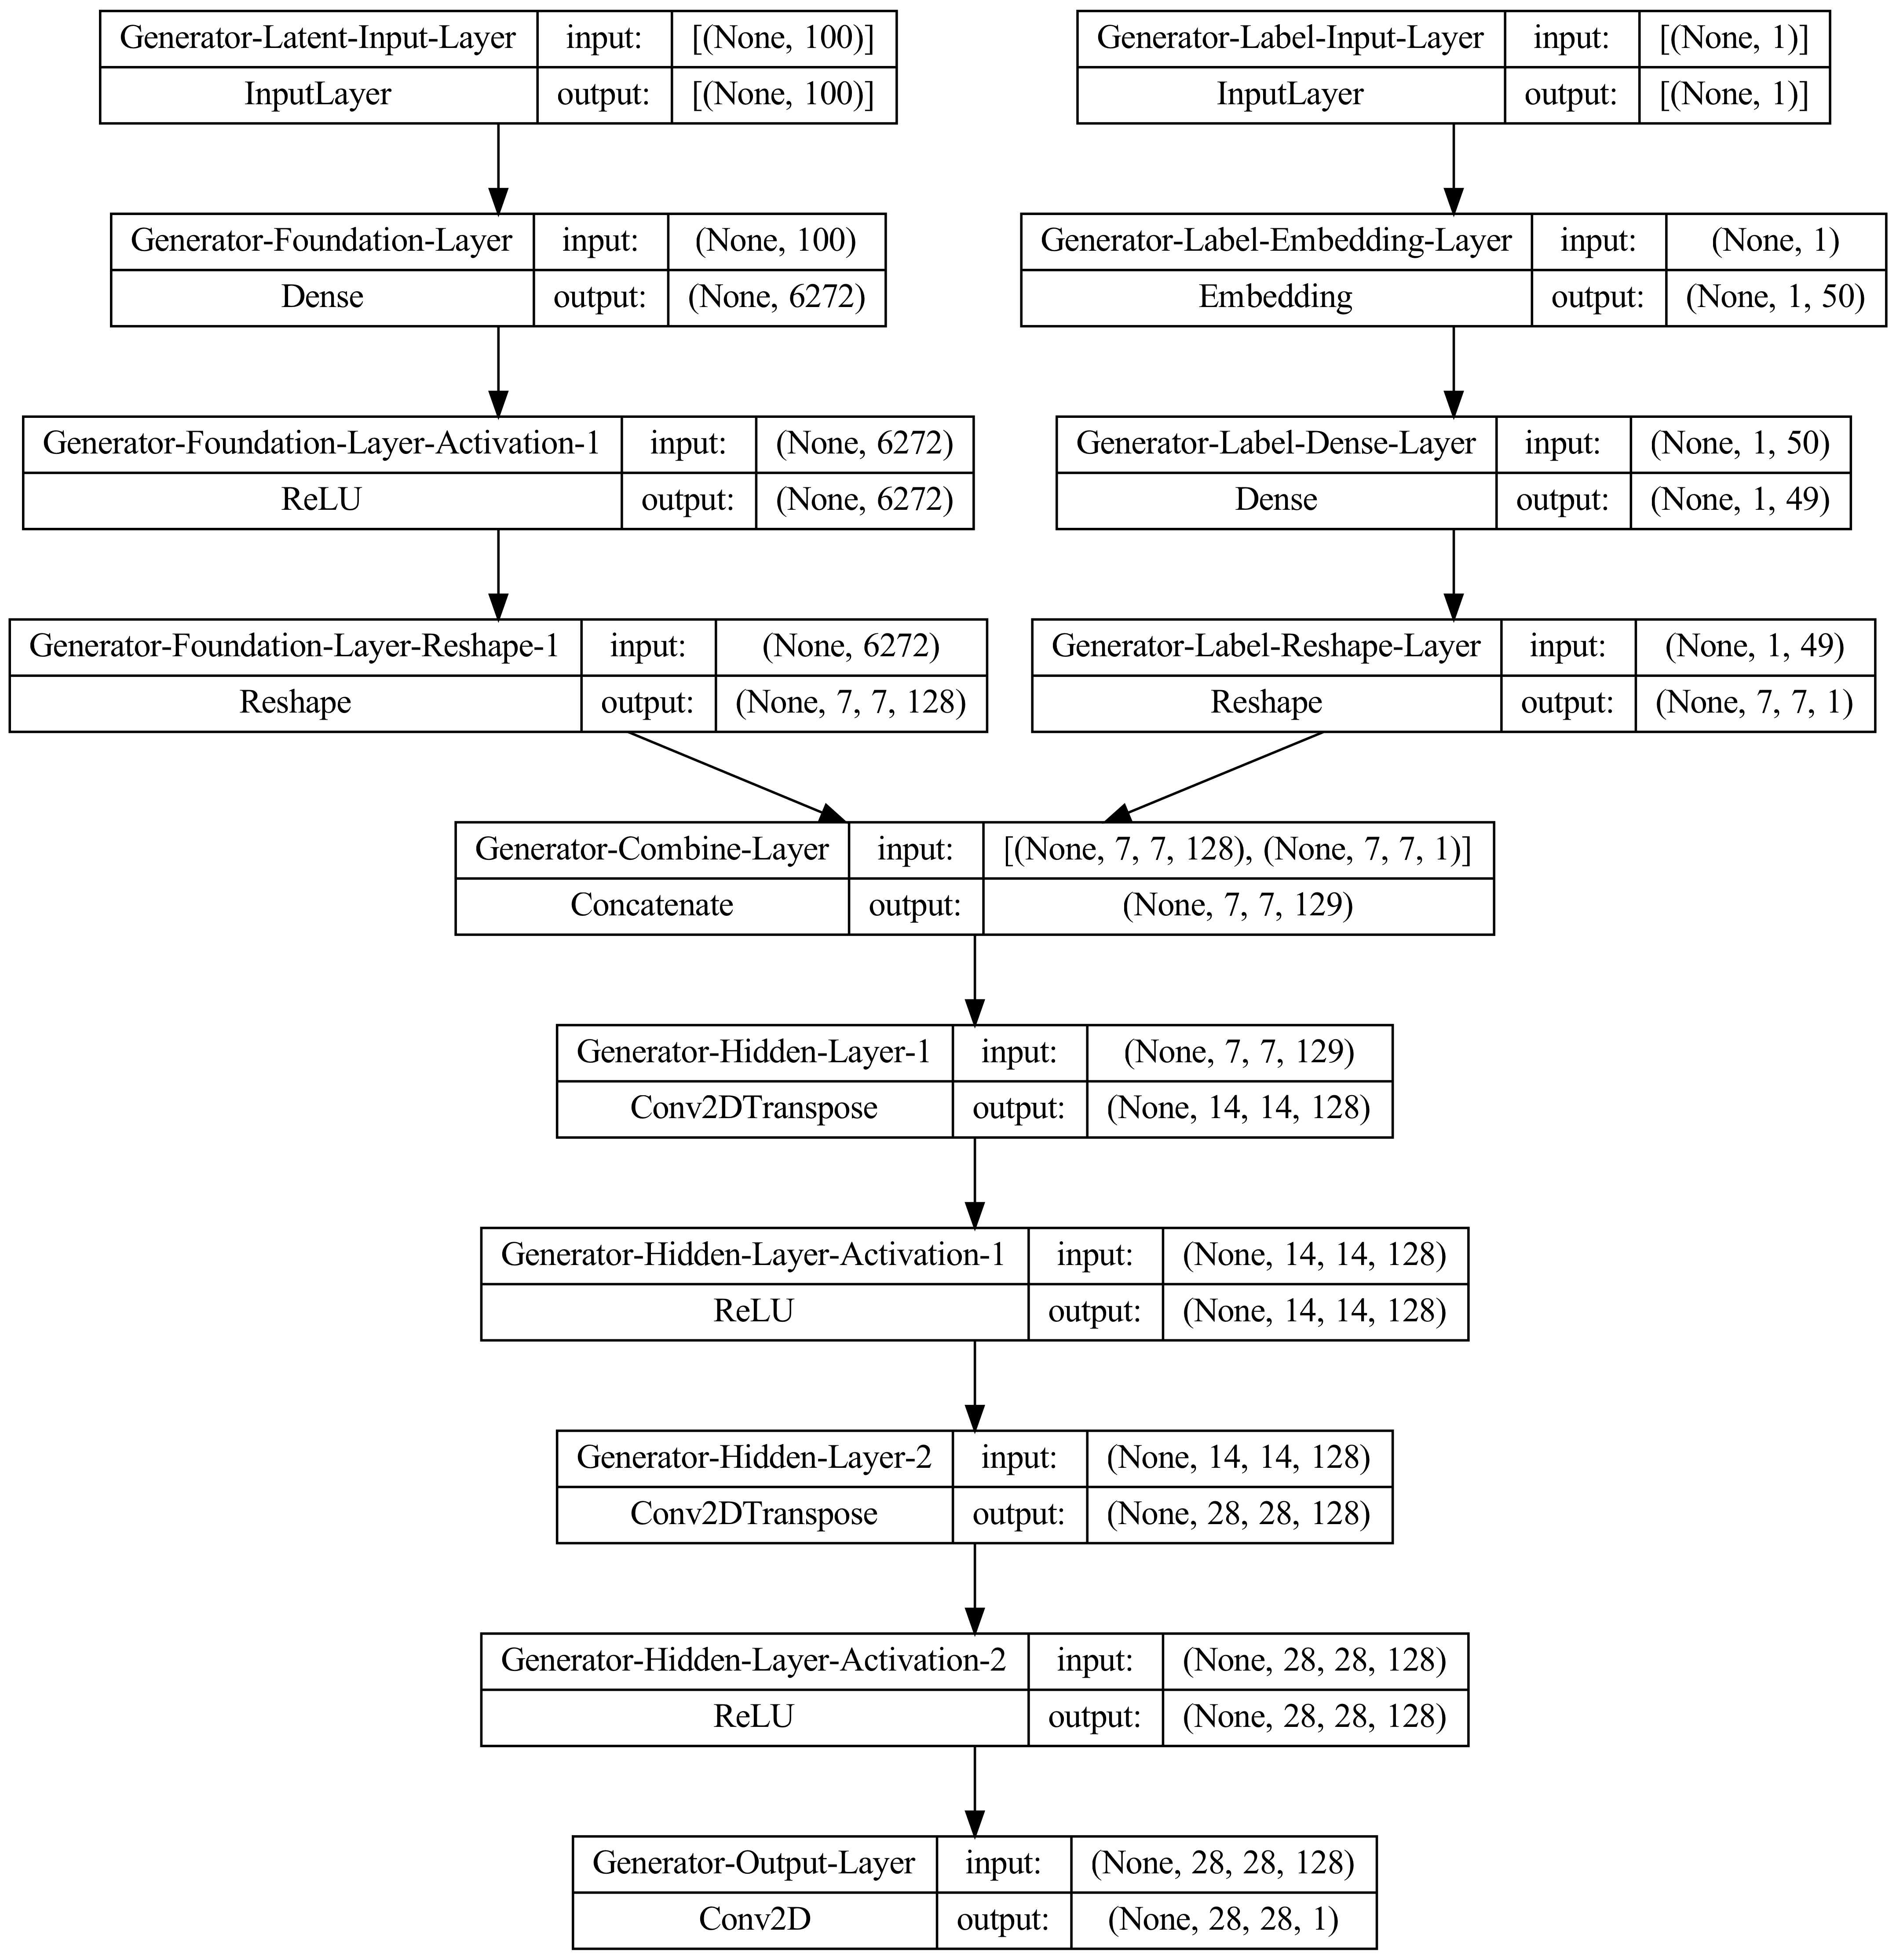

In [27]:
def generator(latent_dim, in_shape=(7,7,1), n_cats=10):
        
    # Label Inputs
    in_label = Input(shape=(1,), name='Generator-Label-Input-Layer') # Input Layer
    lbls = Embedding(n_cats, 50, name='Generator-Label-Embedding-Layer')(in_label) # Embed label to vector
    
    # Scale up to image dimensions
    n_nodes = in_shape[0] * in_shape[1] 
    lbls = Dense(n_nodes, name='Generator-Label-Dense-Layer')(lbls)
    lbls = Reshape((in_shape[0], in_shape[1], 1), name='Generator-Label-Reshape-Layer')(lbls) # New shape

    # Generator Inputs (latent vector)
    in_latent = Input(shape=latent_dim, name='Generator-Latent-Input-Layer')
    
    # Image Foundation 
    n_nodes = 7 * 7 * 128 # number of nodes in the initial layer
    g = Dense(n_nodes, name='Generator-Foundation-Layer')(in_latent)
    g = ReLU(name='Generator-Foundation-Layer-Activation-1')(g)
    g = Reshape((in_shape[0], in_shape[1], 128), name='Generator-Foundation-Layer-Reshape-1')(g)
    
    # Combine both inputs so it has two channels
    concat = Concatenate(name='Generator-Combine-Layer')([g, lbls])

    # Hidden Layer 1
    g = Conv2DTranspose(filters=128, kernel_size=(4,4), strides=(2,2), padding='same', name='Generator-Hidden-Layer-1')(concat)
    g = ReLU(name='Generator-Hidden-Layer-Activation-1')(g)
    
    # Hidden Layer 2
    g = Conv2DTranspose(filters=128, kernel_size=(4,4), strides=(2,2), padding='same', name='Generator-Hidden-Layer-2')(g)
    g = ReLU(name='Generator-Hidden-Layer-Activation-2')(g)
    
    # Output Layer (Note, we use 1 filter since we have a greysclae image. Color image would have three
    output_layer = Conv2D(filters=1, kernel_size=(7,7), activation='tanh', padding='same', name='Generator-Output-Layer')(g)
    
    # Define model
    model = Model([in_latent, in_label], output_layer, name='Generator')
    return model

# Instantiate
latent_dim=100 # Our latent space has 100 dimensions. We can change it to any number
gen_model = generator(latent_dim)

# Show model summary and plot model diagram
gen_model.summary()
plot_model(gen_model, show_shapes=True, show_layer_names=True, dpi=400, to_file=main_dir+'/pics/generator_structure.png')

Step 3.2 - Discriminator model

Model: "Discriminator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Discriminator-Label-Input-Laye  [(None, 1)]         0           []                               
 r (InputLayer)                                                                                   
                                                                                                  
 Discriminator-Label-Embedding-  (None, 1, 50)       500         ['Discriminator-Label-Input-Layer
 Layer (Embedding)                                               [0][0]']                         
                                                                                                  
 Discriminator-Label-Dense-Laye  (None, 1, 784)      39984       ['Discriminator-Label-Embedding-L
 r (Dense)                                                       ayer[0][0]']         

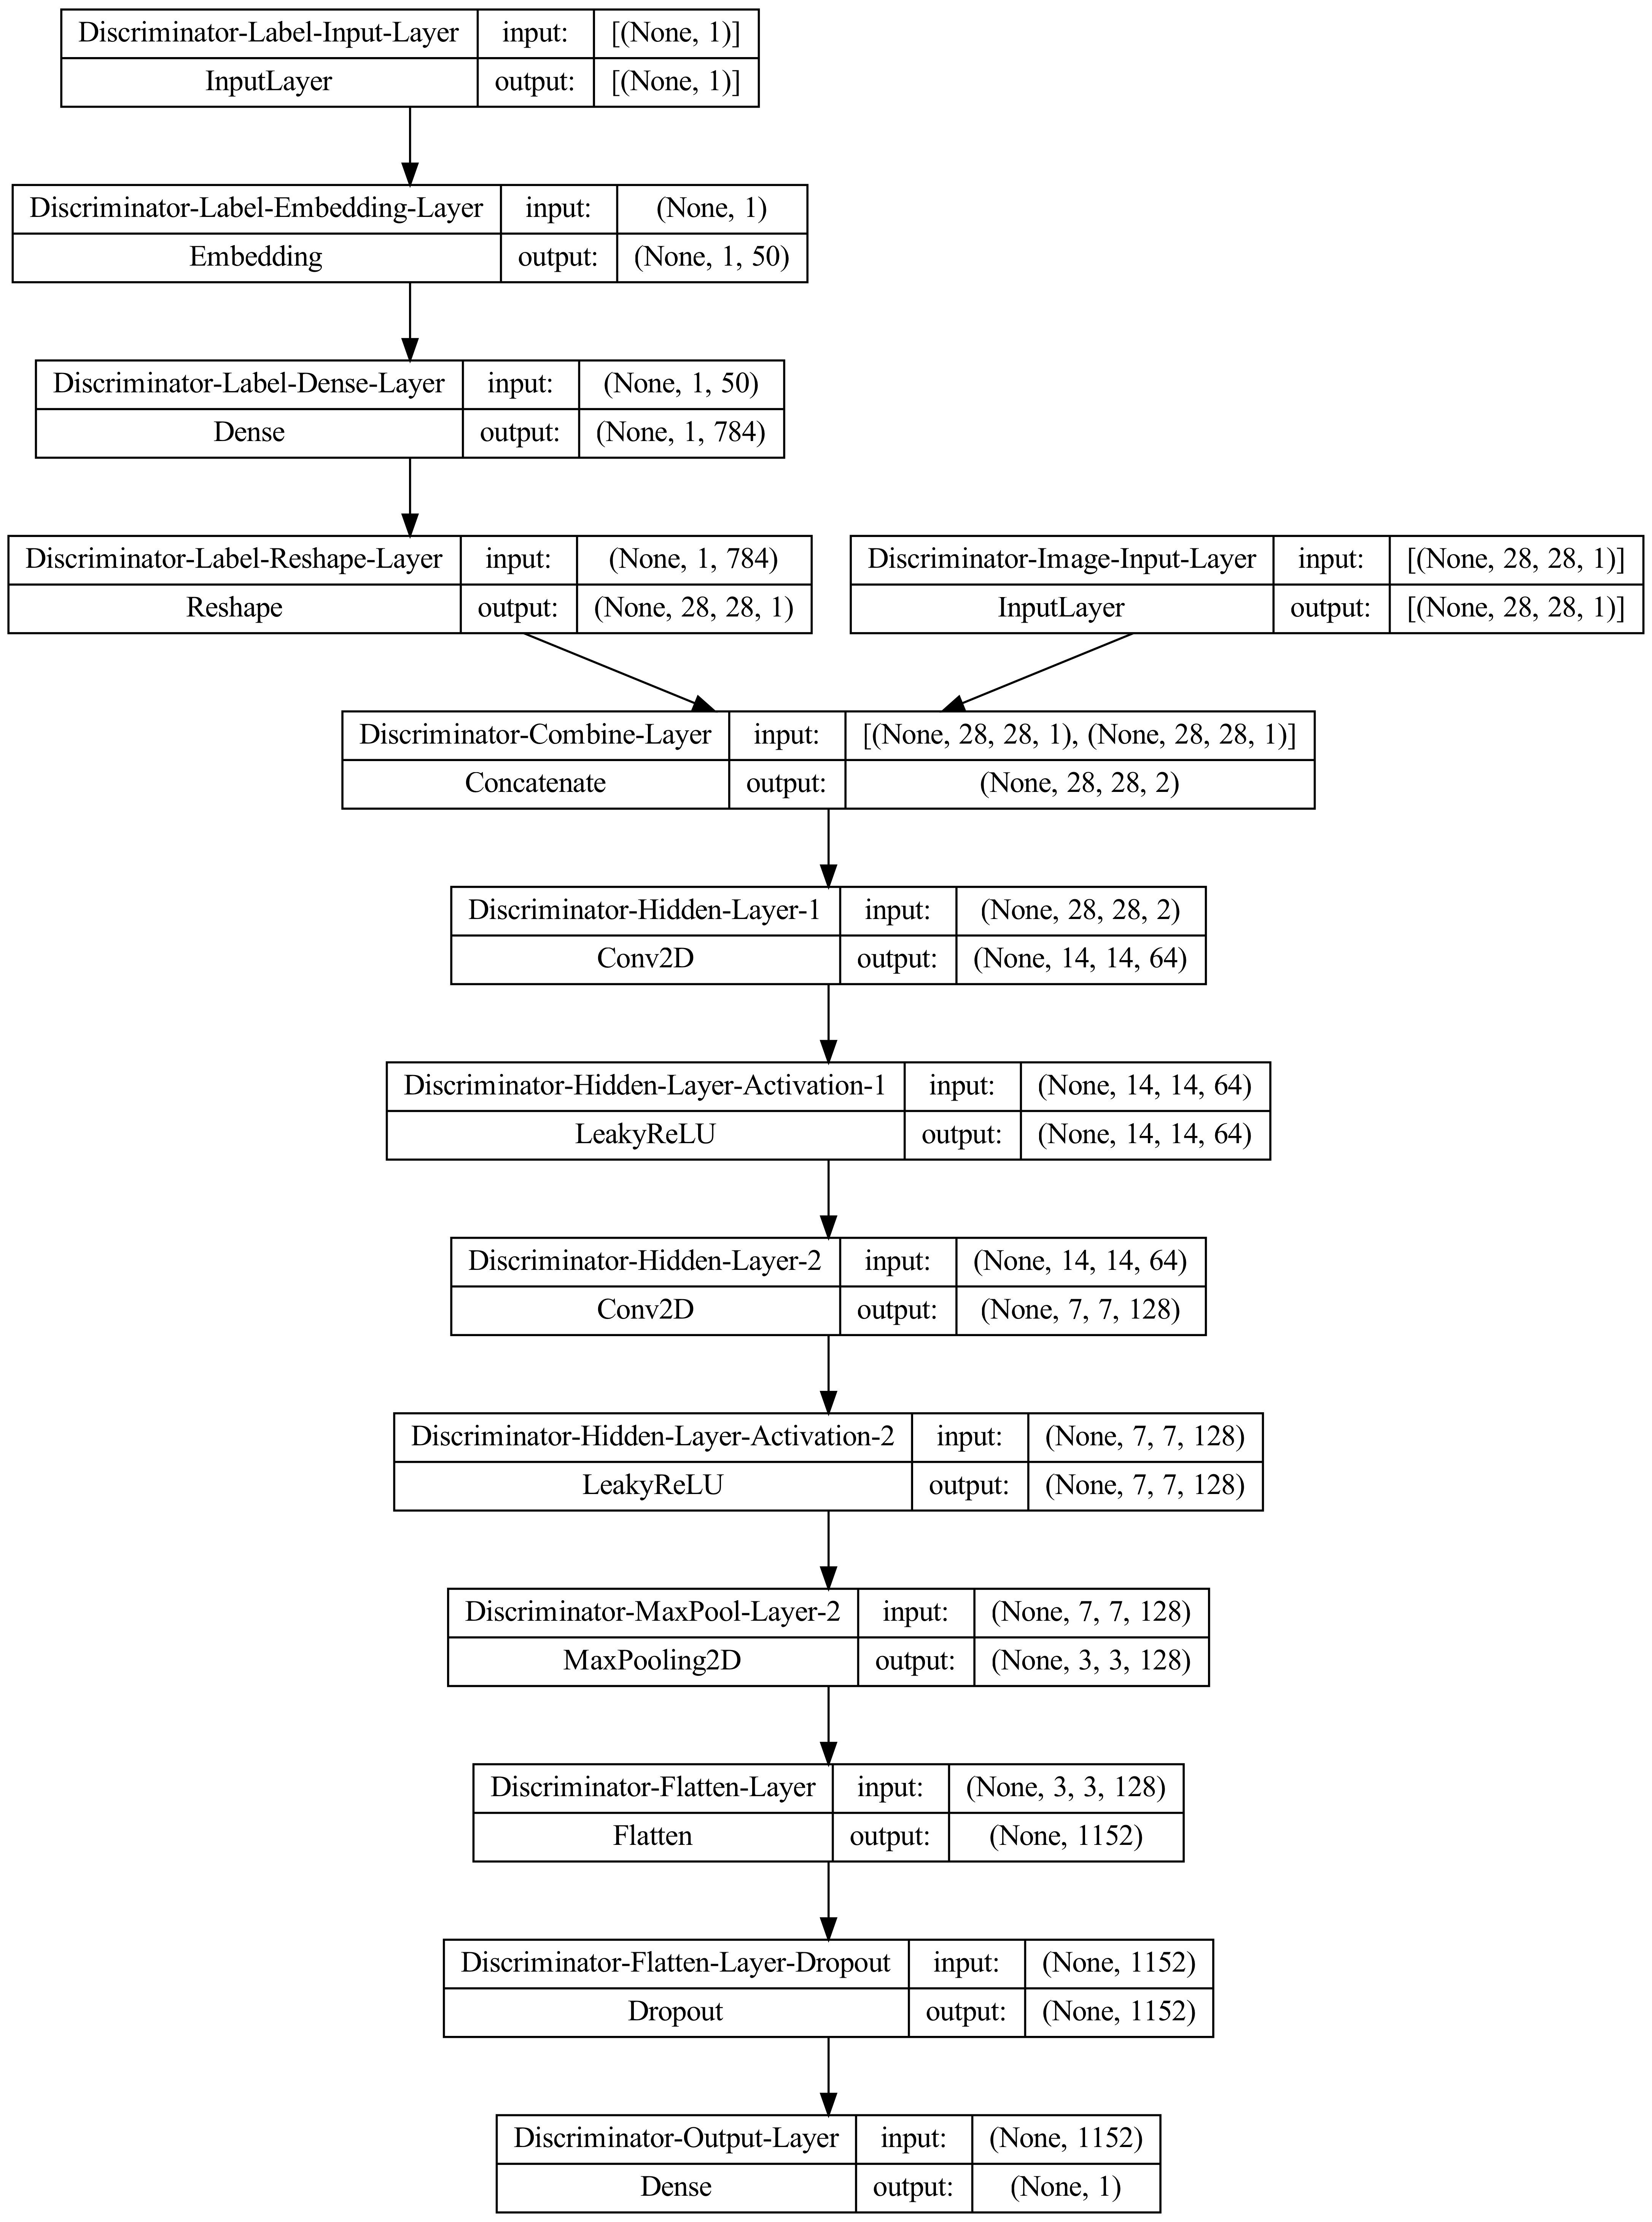

In [28]:
def discriminator(in_shape=(28,28,1), n_cats=10):

    # Label Inputs
    in_label = Input(shape=(1,), name='Discriminator-Label-Input-Layer') # Input Layer
    lbls = Embedding(n_cats, 50, name='Discriminator-Label-Embedding-Layer')(in_label) # Embed label to vector

    # Scale up to image dimensions
    n_nodes = in_shape[0] * in_shape[1] 
    lbls = Dense(n_nodes, name='Discriminator-Label-Dense-Layer')(lbls)
    lbls = Reshape((in_shape[0], in_shape[1], 1), name='Discriminator-Label-Reshape-Layer')(lbls) # New shape

    # Image Inputs
    in_image = Input(shape=in_shape, name='Discriminator-Image-Input-Layer')

    # Combine both inputs so it has two channels
    concat = Concatenate(name='Discriminator-Combine-Layer')([in_image, lbls])

    # Hidden Layer 1
    h = Conv2D(filters=64, kernel_size=(3,3), strides=(2,2), padding='same', name='Discriminator-Hidden-Layer-1')(concat)
    h = LeakyReLU(alpha=0.2, name='Discriminator-Hidden-Layer-Activation-1')(h)

    # Hidden Layer 2
    h = Conv2D(filters=128, kernel_size=(3,3), strides=(2,2), padding='same', name='Discriminator-Hidden-Layer-2')(h)
    h = LeakyReLU(alpha=0.2, name='Discriminator-Hidden-Layer-Activation-2')(h)
    h = MaxPool2D(pool_size=(3,3), strides=(2,2), padding='valid', name='Discriminator-MaxPool-Layer-2')(h) # Max Pool

    # Flatten and Output Layers
    h = Flatten(name='Discriminator-Flatten-Layer')(h) # Flatten the shape
    h = Dropout(0.2, name='Discriminator-Flatten-Layer-Dropout')(h) # Randomly drop some connections for better generalization

    output_layer = Dense(1, activation='sigmoid', name='Discriminator-Output-Layer')(h) # Output Layer

    # Define model
    model = Model([in_image, in_label], output_layer, name='Discriminator')

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5), metrics=['accuracy'])
    return model

# Instantiate
dis_model = discriminator()

# Show model summary and plot model diagram
dis_model.summary()
plot_model(dis_model, show_shapes=True, show_layer_names=True, dpi=400, to_file=main_dir+'/pics/discriminator_structure.png')

Step 3.3 - Combine Generator and Discriminator models into trainable GAN

In [ ]:
def def_gan(generator, discriminator):
    
    # We don't want to train the weights of discriminator at this stage. Hence, make it not trainable
    discriminator.trainable = False
    
    # Get Generator inputs / outputs
    gen_latent, gen_label = generator.input # Latent and label inputs from the generator
    gen_output = generator.output # Generator output image
    
    # Connect image and label from the generator to use as input into the discriminator
    gan_output = discriminator([gen_output, gen_label])
    
    # Define GAN model
    model = Model([gen_latent, gen_label], gan_output, name="cDCGAN")
    
    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return model

# Instantiate
gan_model = def_gan(gen_model, dis_model)

# Show model summary and plot model diagram
gan_model.summary()
plot_model(gan_model, show_shapes=True, show_layer_names=True, dpi=400, to_file=main_dir+'/pics/dcgan_structure.png')

Step 4 - Setup functions to:
- sample the latent space
- sample real images
- generate fake images with the generator model

Set up a function to sample real images


In [ ]:
"""
- picks real MNIST images + their true labels
- gives them to D with target y=1 (“real”)
"""
def real_samples(dataset, categories, n):
    
    # Create a random list of indices
    indx = np.random.randint(0, dataset.shape[0], n)
    
    # Select real data samples (images and category labels) using the list of random indeces from above
    X, cat_labels = dataset[indx], categories[indx]

    # Class labels
    y = np.ones((n, 1))

    return [X, cat_labels], y

Generate points in the latent space, which we will use as inputs for the generator

In [ ]:
"""
- samples random noise z
- samples random labels 0–9
- returns (z, label) pairs for the generator
"""
def latent_vector(latent_dim, n, n_cats=10):
    
    # Generate points in the latent space
    latent_input = np.random.randn(latent_dim * n)
    
    # Reshape into a batch of inputs for the network
    latent_input = latent_input.reshape(n, latent_dim)
    
    # Generate category labels 
    cat_labels = np.random.randint(0, n_cats, n)
    
    return [latent_input, cat_labels]

The below function will use the generator to generate n fake examples together with class labels


In [ ]:
"""
- uses current generator to produce images conditioned on those labels
- gives them to D with target y=0 (“fake”)
"""
def fake_samples(generator, latent_dim, n):
    
    # Generate points in latent space
    latent_output, cat_labels = latent_vector(latent_dim, n)
    
    # Predict outputs (i.e., generate fake samples)
    X = generator.predict([latent_output, cat_labels])
    
    # Create class labels
    y = np.zeros((n, 1))
    
    return [X, cat_labels], y

Step 5 - Setup functions for model performance evaluation and training
- Show a few fake (generated) images during training to get a sense of progress

In [ ]:
def show_fakes(generator, latent_dim, n=10):
    
    # Get fake (generated) samples
    x_fake, y_fake = fake_samples(generator, latent_dim, n)
    
    # Rescale from [-1, 1] to [0, 1]
    X_tst = (x_fake[0] + 1) / 2.0
    
    # Display fake (generated) images
    fig, axs = plt.subplots(2, 5, sharey=False, tight_layout=True, figsize=(12,6), facecolor='white')
    k=0
    for i in range(0,2):
        for j in range(0,5):
            axs[i,j].matshow(X_tst[k], cmap='gray')
            axs[i,j].set(title=x_fake[1][k])
            axs[i,j].axis('off')
            k=k+1
    plt.show() 

Define a function to train our cDCGAN model (generator and discriminator)


In [29]:
"""
A) Train Discriminator
- D learns: (real image, real label) → 1
- D learns: (generated image, same label used to generate it) → 0

B) Train Generator (through gan_model)
- sample (z, label)
- set target y_gan=1
- update G so that D would classify its outputs as “real”

That is the standard adversarial “alternate updates” loop.
"""

def train(g_model, d_model, gan_model, dataset, categories, latent_dim, n_epochs=10, n_batch=128, n_eval=200):
    # Number of batches to use per each epoch
    batch_per_epoch = int(dataset.shape[0] / n_batch)
    print(' batch_per_epoch: ',  batch_per_epoch)
    # Our batch to train the discriminator will consist of half real images and half fake (generated) images
    half_batch = int(n_batch / 2)
    
    # We will manually enumare epochs 
    for i in range(n_epochs):
        
        # Enumerate batches over the training set
        for j in range(batch_per_epoch):
    
        # Discriminator training
            # Prep real samples
            [x_real, cat_labels_real], y_real = real_samples(dataset, categories, half_batch)
            #[x_real, cat_labels_real], y_real = generate_real_samples(dataset, half_batch)
            # Train discriminator with real samples
            discriminator_loss1, _ = d_model.train_on_batch([x_real, cat_labels_real], y_real)
            
            # Prep fake (generated) samples
            [x_fake, cat_labels_fake], y_fake = fake_samples(g_model, latent_dim, half_batch)
            # Train discriminator with fake samples
            discriminator_loss2, _ = d_model.train_on_batch([x_fake, cat_labels_fake], y_fake)


        # Generator training
            # Get values from the latent space to be used as inputs for the generator
            [latent_input, cat_labels] = latent_vector(latent_dim, n_batch)
            # While we are generating fake samples, 
            # we want GAN generator model to create examples that resemble the real ones,
            # hence we want to pass labels corresponding to real samples, i.e. y=1, not 0.
            y_gan = np.ones((n_batch, 1))

            # Train the generator via a composite GAN model
            generator_loss = gan_model.train_on_batch([latent_input, cat_labels], y_gan)
        
        # Summarize training progress and loss
            if (j) % n_eval == 0:
                print('Epoch: %d, Batch: %d/%d, D_Loss_Real=%.3f, D_Loss_Fake=%.3f Gen_Loss=%.3f' % 
                      (i+1, j+1, batch_per_epoch, discriminator_loss1, discriminator_loss2, generator_loss))
                show_fakes(g_model, latent_dim)

## Step 6 - Train the model and display some results
Use the above train function to train our cGAN model

 batch_per_epoch:  468


2026-02-20 15:20:36.138997: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]


2/2 [==============================] - 0s 32ms/step


2026-02-20 15:20:37.060333: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:20:37.302547: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]
	 [[{{node Placeholder/_2}}]]


Epoch: 1, Batch: 1/468, D_Loss_Real=0.640, D_Loss_Fake=0.698 Gen_Loss=0.740
1/1 [==============================] - 0s 71ms/step


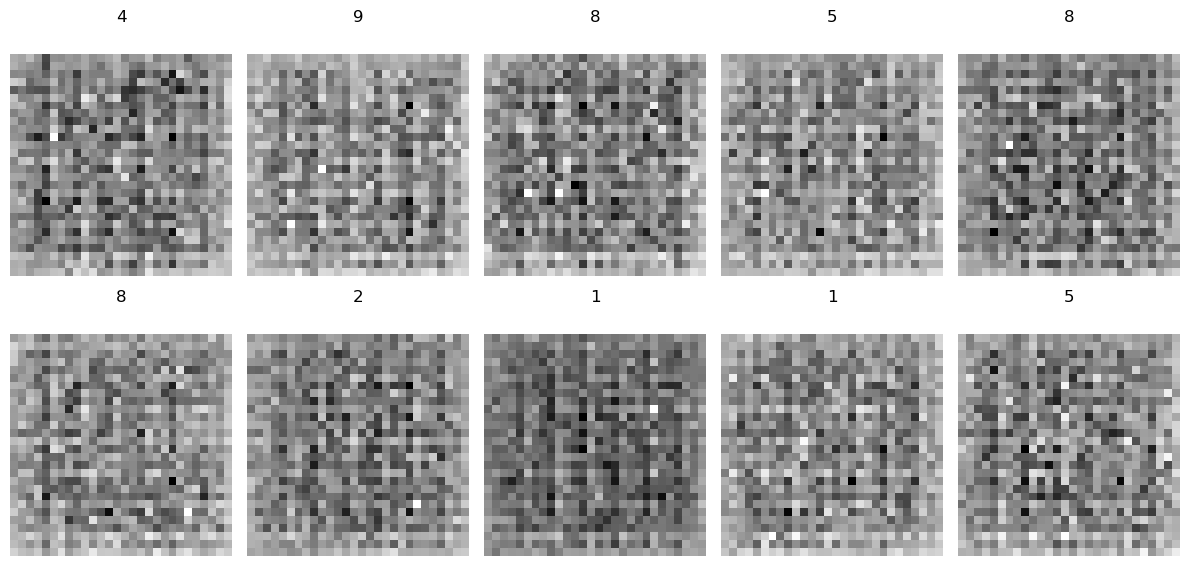

2/2 [==============================] - 0s 30ms/step


2026-02-20 15:20:38.345933: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:20:38.451752: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:20:38.464179: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 29ms/step


2026-02-20 15:20:38.818036: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:20:38.917635: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:20:38.931730: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 29ms/step


...

2/2 [==============================] - 0s 30ms/step


2026-02-20 15:22:13.625013: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:13.720467: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:13.733958: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 29ms/step


2026-02-20 15:22:14.087274: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:14.184990: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:14.196937: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


Epoch: 1, Batch: 201/468, D_Loss_Real=0.000, D_Loss_Fake=0.002 Gen_Loss=0.262
1/1 [==============================] - 0s 23ms/step


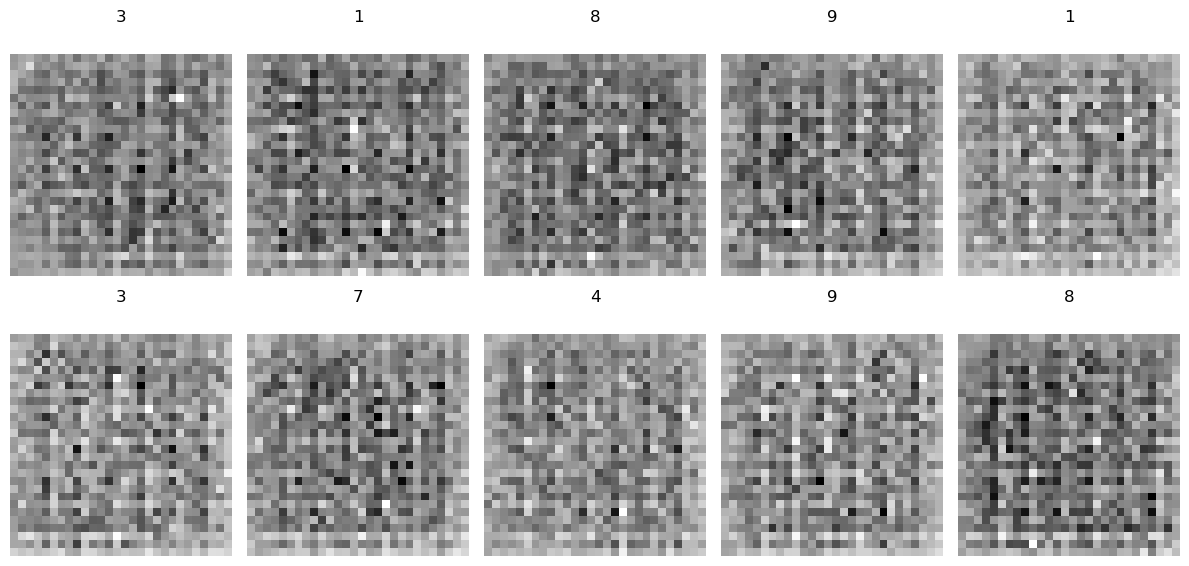

2/2 [==============================] - 0s 45ms/step


2026-02-20 15:22:15.931892: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:16.066330: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:16.079028: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 31ms/step


2026-02-20 15:22:16.442771: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:16.546544: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:22:16.563773: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 32ms/step


...

2/2 [==============================] - 0s 31ms/step


2026-02-20 15:23:47.568675: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:47.670420: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:47.683501: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 30ms/step


2026-02-20 15:23:48.017995: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:48.114677: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:48.127121: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


Epoch: 1, Batch: 401/468, D_Loss_Real=0.000, D_Loss_Fake=0.000 Gen_Loss=0.222
1/1 [==============================] - 0s 22ms/step


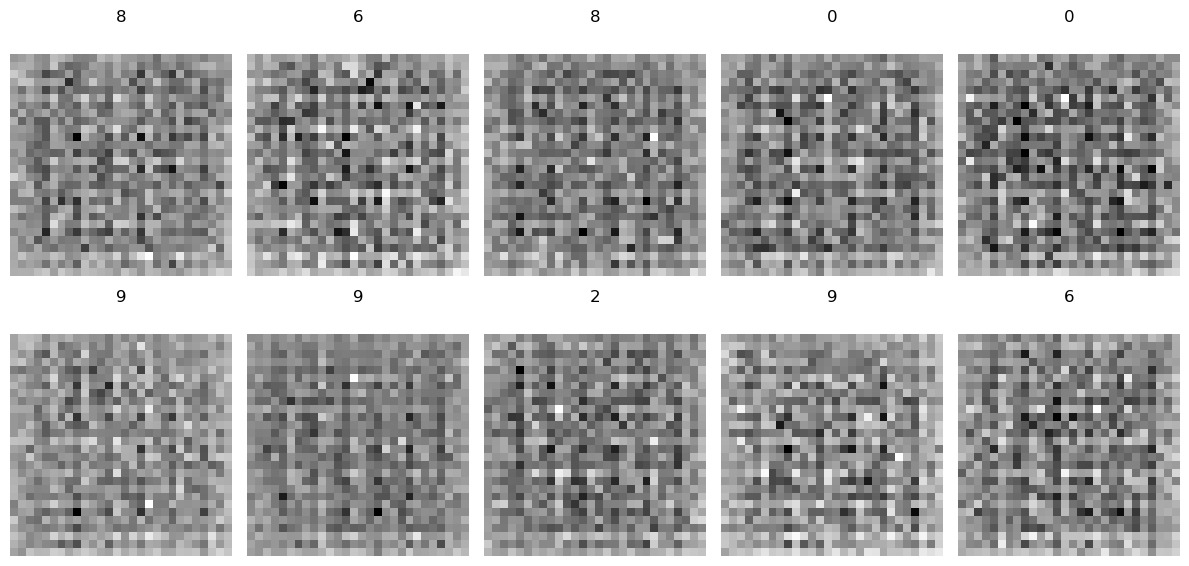

2/2 [==============================] - 0s 30ms/step


2026-02-20 15:23:48.965380: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:49.074280: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:49.100255: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 30ms/step


2026-02-20 15:23:49.443759: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:49.538425: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:23:49.551211: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 30ms/step


...

2/2 [==============================] - 0s 31ms/step


2026-02-20 15:24:14.727950: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:24:14.832066: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:24:14.845209: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


2/2 [==============================] - 0s 34ms/step


2026-02-20 15:24:15.188653: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:24:15.290599: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [64,1]
	 [[{{node Placeholder/_2}}]]
2026-02-20 15:24:15.304728: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_2' with dtype float and shape [128,1]


KeyboardInterrupt: 

In [30]:
# Train cDCGAN model for 10 epochs
train(gen_model, dis_model, gan_model, data, y_train, latent_dim)

## Step 7 - Save the model and use to it to generate images
Save the generator model

In [ ]:
# We need to compile the generator to avoid a warning. This is because we have previously only copiled within the larger cDCGAN model
gen_model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
# Save the Generator on your drive
gen_model.save(main_dir+'/data/cgan_generator.h5')

Generate and display images


4/4 [==============================] - 0s 22ms/step


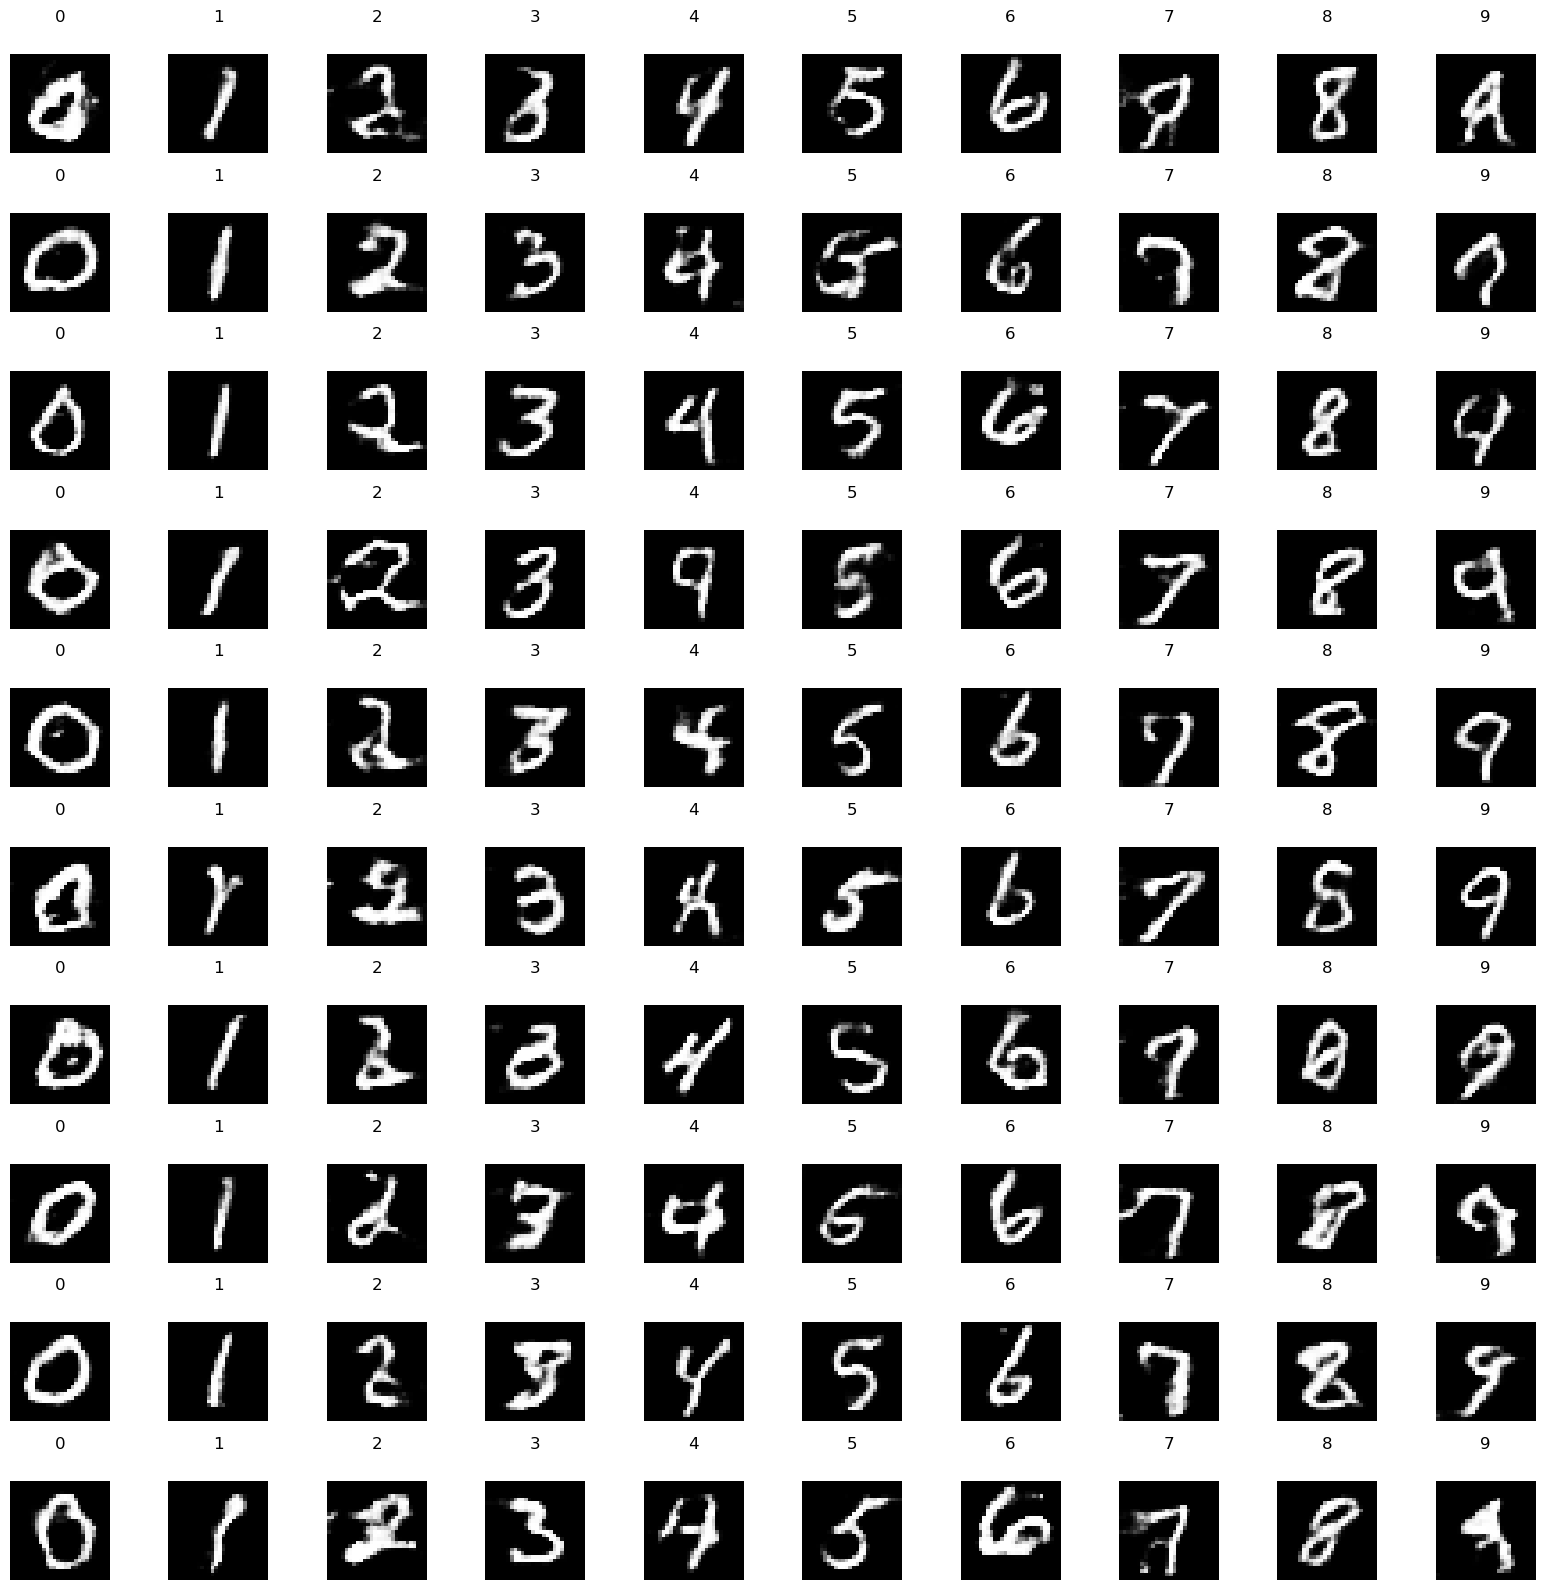

In [26]:
# Generate latent points
latent_points, _ = latent_vector(100, 100)

# Specify labels that we want (0-9 repeated 10 times)
labels = np.asarray([x for _ in range(10) for x in range(10)])

# Load previously saved generator model
model = load_model(main_dir+'/data/cgan_generator.h5')

# Generate images
gen_imgs  = model.predict([latent_points, labels])

# Scale from [-1, 1] to [0, 1]
gen_imgs = (gen_imgs + 1) / 2.0

# Display images
fig, axs = plt.subplots(10, 10, sharey=False, tight_layout=True, figsize=(16,16), facecolor='white')
k=0
for i in range(0,10):
    for j in range(0,10):
        axs[i,j].matshow(gen_imgs[k], cmap='gray')
        axs[i,j].set(title=labels[k])
        axs[i,j].axis('off')
        k=k+1
plt.show() 

# The rows represent diversity in latent space, not epochs.
# Result image shows clear class conditioning
## End of Program!